# code_n1 - SpeedNet 기반 6시간 간격 태양풍 속도 예측

`sample_code.ipynb`(baseline)의 구조를 그대로 유지하면서, 아래 논문의 **SpeedNet**을 이식한 버전입니다.

> Abraham-Alowonle, J. J., Hamada, A., Abdelwahab, M., Kusano, K., & Mahrous, A. (2026).
> *Deep Learning-Based Prediction of High-Speed Solar Wind Streams: Spatio-Temporal Dependencies in Coronal Hole Dynamics.*
> Earth and Space Science, 13, e2025EA004523.

## baseline 대비 바뀐 곳 (이 3군데만 바뀌었습니다)

| 섹션 | baseline | code_n1 (SpeedNet) |
|---|---|---|
| 2. 전처리 | 원본 512x512 -> 64x64 grayscale, `/255` | **off-limb 제거 -> Stonyhurst 투영 -> 로그 스케일 + 데이터셋 고정 mu/sigma 표준화 -> 193 A 동적 임계화로 코로나 홀(CH) 이진맵 생성** (논문 2.1절, Fig. 4) |
| 3. 모델 | 3D CNN + Inception + LSTM(128) | **SpeedNet: Conv.Block x4 (16/32/64/128, Conv+ReLU+MaxPool) -> LSTM(100) -> FFNN(200)** (논문 Fig. 7, Table 4) |
| 4. 학습 | Adam lr=1e-4, RMSE loss, ReduceLROnPlateau, 20 epoch | **논문 Table 4: Adam lr=1e-4 고정(스케줄러 없음), MSE loss, 100 epoch, min val-loss 체크포인트, early stopping patience=20** |

1, 5, 6 섹션(데이터 로드 / 검증 평가 / 제출 파일 생성)은 baseline 코드를 그대로 사용합니다.

## 논문 -> 대회 데이터로 옮기면서 조정한 부분

- 논문은 193/171/304 A 3채널을 쓰지만 대회는 **193/211 A만** 제공됩니다.
  그래서 3번째 채널을 논문의 **SpeedNet-BM용 CH 이진맵(193 A에서 생성)** 으로 채워
  SpeedNet-EUV와 SpeedNet-BM을 한 입력에 합친 형태로 구성했습니다.
- 논문은 맵 1장 -> 속도 1개(지연 1~5일)를 예측합니다. 대회는 **20시점 -> 12개 예측**이므로
  CNN을 시점별로 공유 적용한 뒤 LSTM(100)이 20시점을 훑도록 했습니다(baseline과 동일한 시간축 처리).
- 논문이 강조한 **중심자오선 +-10도 CH 면적**(Fig. 4f 빨간 선)을 시점별 스칼라 특징으로 뽑아
  baseline의 wind 브랜치 입력에 붙였습니다.
- 논문의 batch=12는 학습 샘플 1,060개 기준입니다. 대회 학습 데이터는 9,607개라 batch=12면
  epoch당 801 step이 되어 20분 예산을 넘깁니다. **batch size만** 상향했고
  (`PAPER_EXACT_BATCH_SIZE=True`로 논문값 복원 가능) 나머지 하이퍼파라미터는 논문 그대로입니다.
- 시간 제약상 5-fold 교차검증/앙상블은 사용하지 않고 제공된 train/validation 분리만 사용합니다
  (대회 규정상 validation을 학습에 합치는 것도 금지).


In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import gc
import json
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

# Python, NumPy, PyTorch의 seed를 같게 설정
SEED = 777
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# notebook과 같은 위치의 기본 데이터/출력 경로를 사용합니다.
DATA_ROOT = Path("public_dataset/competition_dataset_6h")
OUTPUT_DIR = Path("outputs/speednet_n1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# 전처리 cache는 read-only일 수 있는 DATA_ROOT 대신 작업 경로 아래에 만듭니다.
CACHE_ROOT = Path("cache/speednet_n1")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR = Path("submission")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

# --- 전체 실행 시간 예산 ---------------------------------------------------
# 20분 안에 submission.csv까지 나와야 하므로 학습 루프가 벽시계 시간을 보고 스스로 멈춥니다.
RUN_STARTED = time.perf_counter()
TOTAL_BUDGET_SECONDS = 20 * 60
INFERENCE_RESERVE_SECONDS = 150   # test 추론 + submission 저장용으로 남겨둘 시간


def elapsed_seconds():
    return time.perf_counter() - RUN_STARTED


def remaining_seconds():
    return TOTAL_BUDGET_SECONDS - elapsed_seconds()


IMAGE_SIZE = 64
CHANNELS = ("193", "211")
# 모델 입력 채널: 논문 Eq.(2)의 3채널 EUV 맵 자리에 [193, 211, CH 이진맵]을 넣습니다.
MAP_CHANNELS = ("193", "211", "ch_binary")

# --- 논문 2.1절 / Fig. 4 전처리 파라미터 -----------------------------------
PROJECTION_LON_LIMIT = 75.0     # Fig. 4d bounding box: 중심자오선 기준 경도 범위
PROJECTION_LAT_LIMIT = 75.0     # Fig. 4d bounding box: 위도 범위
PROJECTION_SUPERSAMPLE = 4      # 투영 격자 anti-aliasing 배율
LIMB_MARGIN = 0.97              # Fig. 4b off-limb 제거: 원반 반지름의 97% 안쪽만 유효
CH_AREA_TARGET = 0.10           # 동적 임계값 보정 기준(원반 평균 CH 면적 비율)
CENTRAL_MERIDIAN_BANDS = (10.0, 30.0)   # Fig. 4f 빨간 선 = 중심자오선 +-10도
LOW_LATITUDE_LIMIT = 30.0       # 저위도 CH가 HSS의 주 원인 (논문 1절)
GEOMETRY_SAMPLE = 64            # 태양 원반 중심/반지름 추정에 쓸 이미지 수
THRESHOLD_SAMPLE = 256          # 동적 임계값 보정에 쓸 이미지 수
CACHE_WORKERS = min(16, (os.cpu_count() or 4))

# --- 논문 Table 4 하이퍼파라미터 -------------------------------------------
PAPER_HPARAMS = {
    "conv_blocks": 4,
    "conv_channels": (16, 32, 64, 128),
    "lstm_units": 100,
    "ffnn_units": {"SpeedNet-EUV": 200, "SpeedNet-BM": 400},
    "batch_size": 12,
    "learning_rate": 0.0001,
    "epochs": 100,
    "optimizer": "Adam",
    "loss": "MSE",
    "model_callback": "min validation loss",
    "early_stopping_patience": 20,
}

CONV_CHANNELS = PAPER_HPARAMS["conv_channels"]
LSTM_UNITS = PAPER_HPARAMS["lstm_units"]
FFNN_UNITS = PAPER_HPARAMS["ffnn_units"]["SpeedNet-EUV"]   # EUV 맵 입력이므로 200
LEARNING_RATE = PAPER_HPARAMS["learning_rate"]
EPOCHS = PAPER_HPARAMS["epochs"]
EARLY_STOPPING_PATIENCE = PAPER_HPARAMS["early_stopping_patience"]

# 논문 batch=12는 학습 샘플 1,060개 기준입니다. 대회 학습 데이터는 9,607개라
# 그대로 두면 epoch당 801 step이 되어 20분 예산 안에 학습이 끝나지 않습니다.
PAPER_EXACT_BATCH_SIZE = False
BATCH_SIZE = PAPER_HPARAMS["batch_size"] if PAPER_EXACT_BATCH_SIZE else 64

NUM_WORKERS = min(8, (os.cpu_count() or 4))
# CUDA를 사용할 수 있으면 GPU와 mixed precision(AMP)을 자동으로 사용합니다.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
else:
    print("WARNING: CUDA Unavailable")

print("PyTorch:", torch.__version__)
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("data:", DATA_ROOT.resolve())
print("batch size:", BATCH_SIZE, "(paper:", PAPER_HPARAMS["batch_size"], ")")


PyTorch: 2.5.1+cu124
device: cuda
GPU: NVIDIA A100-SXM4-40GB
data: /home/jovyan/public_dataset/competition_dataset_6h
batch size: 64 (paper: 12 )


## 1. Dataload

baseline과 동일합니다.


In [2]:
IMAGE_COLUMNS = [f"image_{index:02d}" for index in range(20)]
WIND_COLUMNS = [f"wind_{index:02d}" for index in range(20)]
TARGET_COLUMNS = [f"target_{index:02d}" for index in range(12)]

# 세 split은 미리 분리되어 있으며 notebook에서 다시 나누지 않습니다.
info = json.loads((DATA_ROOT / "dataset_info.json").read_text(encoding="utf-8"))
train_inputs = pd.read_csv(DATA_ROOT / "train/inputs.csv")
train_targets_frame = pd.read_csv(DATA_ROOT / "train/targets.csv")
val_inputs = pd.read_csv(DATA_ROOT / "validation/inputs.csv")
val_targets_frame = pd.read_csv(DATA_ROOT / "validation/targets.csv")
test_inputs = pd.read_csv(DATA_ROOT / "test/inputs.csv")
test_ids = pd.read_csv(DATA_ROOT / "test/test_ids.csv")

# 입력과 정답의 sample 순서, ID 중복, split 간 누락/혼입을 학습 전에 검사합니다.
assert train_inputs.sample_id.tolist() == train_targets_frame.sample_id.tolist()
assert val_inputs.sample_id.tolist() == val_targets_frame.sample_id.tolist()
assert test_inputs.sample_id.tolist() == test_ids.sample_id.tolist()
assert train_inputs.sample_id.is_unique
assert val_inputs.sample_id.is_unique
assert test_inputs.sample_id.is_unique
assert set(train_inputs.sample_id).isdisjoint(val_inputs.sample_id)
assert set(train_inputs.sample_id).isdisjoint(test_inputs.sample_id)
assert set(val_inputs.sample_id).isdisjoint(test_inputs.sample_id)
assert set(IMAGE_COLUMNS + WIND_COLUMNS).issubset(train_inputs.columns)
assert set(IMAGE_COLUMNS + WIND_COLUMNS).issubset(val_inputs.columns)
assert set(TARGET_COLUMNS).issubset(train_targets_frame.columns)
assert set(TARGET_COLUMNS).issubset(val_targets_frame.columns)
assert not any(column.startswith("target_") for column in test_inputs.columns)

# 모델 입력에 바로 사용할 수 있도록 target과 row index를 NumPy 배열로 준비합니다.
train_targets = train_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
val_targets = val_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
train_index = np.arange(len(train_inputs), dtype=np.int64)
val_index = np.arange(len(val_inputs), dtype=np.int64)
test_index = np.arange(len(test_inputs), dtype=np.int64)

print(json.dumps(info["counts"], ensure_ascii=False, indent=2))
print("train/validation/test samples:", len(train_index), len(val_index), len(test_index))


{
  "train_samples": 9607,
  "validation_samples": 1199,
  "test_samples": 3868,
  "train_png_per_channel": 10139,
  "validation_png_per_channel": 1408,
  "test_png_per_channel": 4115
}
train/validation/test samples: 9607 1199 3868


## 2. SpeedNet 전처리 - off-limb 제거 -> Stonyhurst 투영 -> 코로나 홀 이진맵

논문 Figure 4의 파이프라인을 그대로 옮겼습니다.

1. **(b) off-limb 제거** - 태양 원반 밖 픽셀은 HSS와 무관한 잡음이므로 버립니다.
   FITS 헤더가 없으므로 train 이미지 일부의 평균 영상에서 원반 중심/반지름을 직접 추정하고,
   투영 격자에서 정사영 거리가 limb의 `LIMB_MARGIN`(97%)을 넘는 점은 관측값 없음으로 처리합니다.
   이 처리를 빼면 원반 밖의 어두운 코로나가 코로나 홀로 오검출됩니다.
2. **(c)(d) Stonyhurst 투영** - 원반 이미지를 헬리오그래픽 경도/위도 격자로 다시 매핑합니다.
   원반 가장자리에서 코로나 홀이 납작하게 찌그러져 보이는 foreshortening이 사라지므로,
   같은 코로나 홀이 자전으로 이동해도 **면적이 일정하게 측정**됩니다.
   Fig. 4d의 bounding box에 맞춰 경도/위도 +-75도 범위만 사용합니다.
3. **(e) 로그 스케일 + 고정 mu/sigma 표준화** - 논문 Eq.(1). 이미지마다 통계를 다시 계산하면
   태양 활동 극대기/극소기의 실제 밝기 차이가 지워지므로, **train split 전체에서 한 번 계산한
   상수 mu/sigma**를 모든 split에 동일하게 적용합니다. (논문의 193 A mu=5.38, sigma=0.70에 대응)
4. **(f) 코로나 홀 이진맵** - 193 A 맵에 동적 임계화(Milosic et al. 2023 방식)를 적용합니다.
   임계값은 이미지별 중앙값에 비례하는 `CH_RATIO x median`이고, 비례상수는 train 표본에서
   평균 CH 면적이 `CH_AREA_TARGET`이 되도록 한 번 보정합니다.
5. **중심자오선 +-10도 CH 면적** - 논문 Fig. 4f의 빨간 선. 중심자오선을 지나는 코로나 홀이
   3~4일 뒤 지구 도달 HSS의 주 원인이므로, 시점별 CH 면적 스칼라를 뽑아 wind 브랜치에 넣습니다.

임계값, 원반 기하, mu/sigma는 **train split에서만** 산출해 validation/test에 그대로 적용합니다(누수 방지).


In [3]:
def open_gray(path):
    with Image.open(path) as image:
        return np.asarray(image.convert("L"), dtype=np.float32)


def unique_filenames(inputs):
    # 여러 sample에서 반복되는 PNG는 고유 파일당 한 번만 전처리합니다.
    return sorted(pd.unique(inputs[IMAGE_COLUMNS].to_numpy().ravel()).tolist())


def subsample(items, count):
    step = max(1, len(items) // count)
    return items[::step][:count]


def estimate_disk_geometry(split, filenames, channel):
    # 논문 Fig. 4b: off-limb 픽셀을 지우려면 태양 원반의 중심과 반지름이 필요합니다.
    # FITS 헤더(RSUN_OBS, CRPIX)가 없으므로 train 영상 평균에서 직접 추정합니다.
    image_root = DATA_ROOT / split / channel
    picked = subsample(filenames, GEOMETRY_SAMPLE)
    accumulator = None
    for filename in picked:
        frame = open_gray(image_root / filename)
        accumulator = frame if accumulator is None else accumulator + frame
    mean_image = accumulator / len(picked)
    height, width = mean_image.shape

    # 밝은 원반 영역의 무게중심을 원반 중심으로 사용합니다.
    bright = mean_image > 0.2 * float(np.percentile(mean_image, 99.5))
    rows, columns = np.nonzero(bright)
    center_y = float(rows.mean())
    center_x = float(columns.mean())

    # 중심에서의 반경별 평균 밝기가 원반 내부 밝기의 35% 아래로 떨어지는 지점을 limb으로 봅니다.
    grid_y, grid_x = np.ogrid[:height, :width]
    radius_map = np.hypot(grid_y - center_y, grid_x - center_x)
    max_radius = int(min(center_x, center_y, width - center_x, height - center_y))
    bins = np.clip(radius_map.astype(np.int64), 0, max_radius)
    total = np.bincount(bins.ravel(), weights=mean_image.ravel(), minlength=max_radius + 1)
    counts = np.bincount(bins.ravel(), minlength=max_radius + 1)
    profile = total / np.maximum(counts, 1)
    interior = float(profile[: max(4, max_radius // 4)].mean())
    inside = np.nonzero(profile > 0.35 * interior)[0]
    radius = float(inside[-1]) if len(inside) else 0.40 * width
    radius = float(np.clip(radius, 0.20 * width, 0.50 * width)) * 0.995

    geometry = {
        "channel": channel,
        "height": int(height),
        "width": int(width),
        "center_x": center_x,
        "center_y": center_y,
        "radius": radius,
    }
    print(f"disk geometry [{channel}]: {width}x{height} "
          f"center=({center_x:.1f},{center_y:.1f}) radius={radius:.1f}px")
    return geometry


def build_projection_grid(geometry, size=IMAGE_SIZE, supersample=PROJECTION_SUPERSAMPLE):
    # Stonyhurst 헬리오그래픽 좌표(경도 x, 위도 y) 격자를 원반 이미지 좌표로 되돌리는 사상.
    # B0(태양 자전축 기울기)은 연중 +-7.25도로 작고 헤더가 없으므로 0으로 둡니다.
    fine = size * supersample
    longitude = np.deg2rad(
        np.linspace(-PROJECTION_LON_LIMIT, PROJECTION_LON_LIMIT, fine, dtype=np.float64)
    )
    latitude = np.deg2rad(
        np.linspace(PROJECTION_LAT_LIMIT, -PROJECTION_LAT_LIMIT, fine, dtype=np.float64)
    )
    longitude_grid, latitude_grid = np.meshgrid(longitude, latitude)
    # 구면 위 점을 관측자 시선 방향으로 정사영한 좌표 (단위: 태양 반지름)
    solar_x = np.cos(latitude_grid) * np.sin(longitude_grid)
    solar_y = np.sin(latitude_grid)
    pixel_x = geometry["center_x"] + solar_x * geometry["radius"]
    pixel_y = geometry["center_y"] - solar_y * geometry["radius"]

    # bilinear 보간 가중치를 미리 만들어 두고 이미지마다 fancy indexing만 수행합니다.
    left = np.clip(np.floor(pixel_x), 0, geometry["width"] - 2).astype(np.int64)
    top = np.clip(np.floor(pixel_y), 0, geometry["height"] - 2).astype(np.int64)
    return {
        "size": size,
        "supersample": supersample,
        "left": left,
        "top": top,
        "weight_x": (pixel_x - left).astype(np.float32),
        "weight_y": (pixel_y - top).astype(np.float32),
    }


def project(frame, grid):
    left, top = grid["left"], grid["top"]
    weight_x, weight_y = grid["weight_x"], grid["weight_y"]
    upper = frame[top, left] * (1.0 - weight_x) + frame[top, left + 1] * weight_x
    lower = frame[top + 1, left] * (1.0 - weight_x) + frame[top + 1, left + 1] * weight_x
    fine = upper * (1.0 - weight_y) + lower * weight_y
    size, supersample = grid["size"], grid["supersample"]
    # supersample 격자를 box 평균으로 줄여 aliasing을 없앱니다.
    return fine.reshape(size, supersample, size, supersample).mean(axis=(1, 3))


# 투영 격자 위의 위도/경도와, 면적 가중치(구면 면적소는 cos(위도)에 비례)
GRID_LATITUDE = np.linspace(PROJECTION_LAT_LIMIT, -PROJECTION_LAT_LIMIT, IMAGE_SIZE)
GRID_LONGITUDE = np.linspace(-PROJECTION_LON_LIMIT, PROJECTION_LON_LIMIT, IMAGE_SIZE)



def build_on_disk_mask(size=IMAGE_SIZE, supersample=PROJECTION_SUPERSAMPLE):
    # 논문 Fig. 4b의 off-limb 제거. +-75도 격자의 모서리는 원반 가장자리 바깥을 찍게 되므로
    # 정사영 거리가 limb의 LIMB_MARGIN을 넘는 격자점은 "관측값 없음"으로 버립니다.
    # (그대로 두면 원반 밖 어두운 코로나가 코로나 홀로 오검출됩니다.)
    # supersample 부분 픽셀이 섞이면 경계에 어두운 띠가 생기므로,
    # 16개 subsample이 모두 원반 안인 격자점만 유효로 봅니다.
    fine = size * supersample
    longitude, latitude = np.meshgrid(
        np.deg2rad(np.linspace(-PROJECTION_LON_LIMIT, PROJECTION_LON_LIMIT, fine)),
        np.deg2rad(np.linspace(PROJECTION_LAT_LIMIT, -PROJECTION_LAT_LIMIT, fine)),
    )
    inside = (
        (np.cos(latitude) * np.sin(longitude)) ** 2 + np.sin(latitude) ** 2
    ) <= LIMB_MARGIN ** 2
    coverage = inside.reshape(size, supersample, size, supersample).mean(axis=(1, 3))
    return coverage >= 1.0 - 1e-9


ON_DISK = build_on_disk_mask()
ON_DISK_FLOAT = ON_DISK.astype(np.float32)
AREA_WEIGHT = (
    np.broadcast_to(
        np.cos(np.deg2rad(GRID_LATITUDE))[:, None].astype(np.float32),
        (IMAGE_SIZE, IMAGE_SIZE),
    )
    * ON_DISK_FLOAT
)
MERIDIAN_MASKS = [np.abs(GRID_LONGITUDE) <= band for band in CENTRAL_MERIDIAN_BANDS]
LOW_LATITUDE_MASK = np.abs(GRID_LATITUDE) <= LOW_LATITUDE_LIMIT
CH_FEATURE_NAMES = (
    "ch_area_full_disk",
    f"ch_area_meridian_{int(CENTRAL_MERIDIAN_BANDS[0])}deg",
    f"ch_area_meridian_{int(CENTRAL_MERIDIAN_BANDS[1])}deg",
    f"ch_area_low_latitude_{int(LOW_LATITUDE_LIMIT)}deg",
)
CH_FEATURE_DIM = len(CH_FEATURE_NAMES)


def coronal_hole_features(binary):
    # 논문 Fig. 4f: 중심자오선 +-10도를 지나는 CH가 3~4일 뒤 지구 HSS의 주 원인.
    features = [float((binary * AREA_WEIGHT).sum() / AREA_WEIGHT.sum())]
    for mask in MERIDIAN_MASKS:
        weight = AREA_WEIGHT[:, mask]
        features.append(float((binary[:, mask] * weight).sum() / weight.sum()))
    weight = AREA_WEIGHT[LOW_LATITUDE_MASK]
    features.append(float((binary[LOW_LATITUDE_MASK] * weight).sum() / weight.sum()))
    return np.asarray(features, dtype=np.float32)


def calibrate_ch_threshold(split, filenames, grid):
    # Milosic et al. (2023)의 동적 임계화: 임계값을 이미지 중앙값에 비례시키고,
    # 비례상수는 train 표본에서 평균 CH 면적이 CH_AREA_TARGET이 되도록 한 번만 맞춥니다.
    image_root = DATA_ROOT / split / CHANNELS[0]
    ratios = []
    for filename in subsample(filenames, THRESHOLD_SAMPLE):
        projected = project(open_gray(image_root / filename), grid)[ON_DISK]
        median = float(np.median(projected))
        if median > 0:
            ratios.append(projected / median)
    pooled = np.concatenate(ratios)
    ch_ratio = float(np.quantile(pooled, CH_AREA_TARGET))
    print(f"on-disk grid points: {int(ON_DISK.sum())}/{ON_DISK.size} "
          f"({ON_DISK.mean():.1%} of the {IMAGE_SIZE}x{IMAGE_SIZE} map)")
    print(f"coronal hole dynamic threshold: I < {ch_ratio:.4f} x median(I)  "
          f"(target area {CH_AREA_TARGET:.0%}, {len(ratios)} images)")
    return ch_ratio


In [4]:
def prepare_speednet_cache(split, inputs, grids, ch_ratio):
    # baseline의 resize cache와 같은 방식이지만, 저장하는 내용이
    # [193 투영맵, 211 투영맵, CH 이진맵]과 CH 면적 특징으로 바뀌었습니다.
    image_root = DATA_ROOT / split
    cache_root = CACHE_ROOT / f"{IMAGE_SIZE}px"
    cache_root.mkdir(parents=True, exist_ok=True)
    array_path = cache_root / f"{split}_maps.npy"
    feature_path = cache_root / f"{split}_ch_features.npy"
    metadata_path = cache_root / f"{split}_metadata.json"
    filenames = unique_filenames(inputs)
    expected = {
        "image_size": IMAGE_SIZE,
        "map_channels": list(MAP_CHANNELS),
        "lon_limit": PROJECTION_LON_LIMIT,
        "lat_limit": PROJECTION_LAT_LIMIT,
        "supersample": PROJECTION_SUPERSAMPLE,
        "limb_margin": LIMB_MARGIN,
        "ch_ratio": ch_ratio,
        "ch_features": list(CH_FEATURE_NAMES),
        "geometry": [grid["geometry"] for grid in grids],
        "filenames": filenames,
    }

    valid = False
    if array_path.exists() and feature_path.exists() and metadata_path.exists():
        try:
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
            cached = np.load(array_path, mmap_mode="r")
            cached_features = np.load(feature_path, mmap_mode="r")
            valid = (
                metadata == expected
                and cached.shape == (len(filenames), len(MAP_CHANNELS), IMAGE_SIZE, IMAGE_SIZE)
                and cached.dtype == np.uint8
                and cached_features.shape == (len(filenames), CH_FEATURE_DIM)
            )
        except (OSError, ValueError, json.JSONDecodeError):
            valid = False

    if not valid:
        # partial 파일에 먼저 완성한 뒤 이름을 바꿔 중단된 cache의 재사용을 막습니다.
        array_temp = array_path.with_name(array_path.name + f".partial.{os.getpid()}")
        feature_temp = feature_path.with_name(feature_path.name + f".partial.{os.getpid()}")
        metadata_temp = metadata_path.with_name(metadata_path.name + f".partial.{os.getpid()}")
        maps = np.lib.format.open_memmap(
            array_temp, mode="w+", dtype=np.uint8,
            shape=(len(filenames), len(MAP_CHANNELS), IMAGE_SIZE, IMAGE_SIZE),
        )
        features = np.zeros((len(filenames), CH_FEATURE_DIM), dtype=np.float32)
        done = [0]

        def build_row(item):
            index, filename = item
            projected = [
                project(open_gray(image_root / channel / filename), grids[position])
                for position, channel in enumerate(CHANNELS)
            ]
            median = float(np.median(projected[0][ON_DISK]))
            # 논문 Fig. 4f: 193 A 맵의 동적 임계화로 코로나 홀 이진맵을 만듭니다.
            # off-limb 격자점은 관측값이 없으므로 CH 후보에서 제외합니다.
            binary = ((projected[0] < ch_ratio * median) & ON_DISK).astype(np.float32)
            for position in range(len(CHANNELS)):
                maps[index, position] = np.clip(
                    projected[position] * ON_DISK_FLOAT, 0, 255
                ).astype(np.uint8)
            maps[index, len(CHANNELS)] = (binary * 255.0).astype(np.uint8)
            features[index] = coronal_hole_features(binary)
            done[0] += 1
            if done[0] % 2000 == 0 or done[0] == len(filenames):
                print(f"{split} speednet preprocess: {done[0]}/{len(filenames)}", flush=True)

        with ThreadPoolExecutor(max_workers=CACHE_WORKERS) as pool:
            list(pool.map(build_row, enumerate(filenames)))

        maps.flush()
        del maps
        # np.save는 경로 인자에 .npy를 덧붙이므로 파일 객체로 넘깁니다.
        with open(feature_temp, "wb") as handle:
            np.save(handle, features)
        metadata_temp.write_text(
            json.dumps(expected, ensure_ascii=False) + "\n", encoding="utf-8"
        )
        array_temp.replace(array_path)
        feature_temp.replace(feature_path)
        metadata_temp.replace(metadata_path)
        print(f"created speednet cache: {array_path.resolve()}")
    else:
        print(f"reusing speednet cache: {array_path.resolve()}")

    image_array = np.load(array_path, mmap_mode="r")
    feature_array = np.load(feature_path)
    image_index = {filename: index for index, filename in enumerate(filenames)}
    return image_array, feature_array, image_index


# 원반 기하 / 동적 임계값은 train split에서만 산출해 validation, test에 그대로 씁니다.
train_filenames = unique_filenames(train_inputs)
GRIDS = []
for channel in CHANNELS:
    geometry = estimate_disk_geometry("train", train_filenames, channel)
    grid = build_projection_grid(geometry)
    grid["geometry"] = geometry
    GRIDS.append(grid)

CH_RATIO = calibrate_ch_threshold("train", train_filenames, GRIDS[0])

train_image_array, train_ch_features, train_image_index = prepare_speednet_cache(
    "train", train_inputs, GRIDS, CH_RATIO
)
val_image_array, val_ch_features, val_image_index = prepare_speednet_cache(
    "validation", val_inputs, GRIDS, CH_RATIO
)
test_image_array, test_ch_features, test_image_index = prepare_speednet_cache(
    "test", test_inputs, GRIDS, CH_RATIO
)
print(f"preprocess done at {elapsed_seconds():.0f}s (budget {TOTAL_BUDGET_SECONDS}s)")


disk geometry [193]: 512x512 center=(256.6,253.7) radius=230.8px
disk geometry [211]: 512x512 center=(256.4,254.9) radius=242.8px
on-disk grid points: 3572/4096 (87.2% of the 64x64 map)
coronal hole dynamic threshold: I < 0.0607 x median(I)  (target area 10%, 256 images)
reusing speednet cache: /home/jovyan/cache/speednet_n1/64px/train_maps.npy
reusing speednet cache: /home/jovyan/cache/speednet_n1/64px/validation_maps.npy
reusing speednet cache: /home/jovyan/cache/speednet_n1/64px/test_maps.npy
preprocess done at 3s (budget 1200s)


In [5]:
def compute_log_statistics(image_array, sample_rows=2048):
    # 논문 Eq.(1): 이미지별 통계가 아니라 데이터셋 전체에서 한 번 구한 고정 mu/sigma를 씁니다.
    # (논문 값: 193 A mu=5.38 sigma=0.70 - FITS DN 기준이라 8-bit PNG인 대회 데이터에는
    #  그대로 쓸 수 없어 같은 방식으로 train split에서 재계산합니다.)
    rows = np.unique(
        np.linspace(0, len(image_array) - 1, min(sample_rows, len(image_array))).astype(np.int64)
    )
    sample = np.log1p(np.asarray(image_array[rows][:, : len(CHANNELS)], dtype=np.float32))
    # off-limb 격자점(값 0)은 통계에서 제외합니다.
    sample = sample[:, :, ON_DISK]
    mean = sample.mean(axis=(0, 2)).astype(np.float32)
    std = np.maximum(sample.std(axis=(0, 2)), 1e-6).astype(np.float32)
    return mean, std


LOG_MEAN, LOG_STD = compute_log_statistics(train_image_array)
for position, channel in enumerate(CHANNELS):
    print(f"AIA {channel} A : mu_log={LOG_MEAN[position]:.3f}  sigma_log={LOG_STD[position]:.3f}")

WIND_FEATURE_DIM = 20 + 20 * CH_FEATURE_DIM


class SpeedNetDataset(Dataset):
    def __init__(self, image_array, feature_array, image_index, inputs, indexes,
                 log_mean, log_std, targets=None):
        self.image_array = image_array
        self.feature_array = feature_array
        # CSV의 파일명을 cache row 번호로 한 번만 변환해 epoch별 문자열 탐색을 없앱니다.
        self.image_indexes = np.asarray([
            [image_index[filename] for filename in row]
            for row in inputs[IMAGE_COLUMNS].itertuples(index=False, name=None)
        ], dtype=np.int32)
        # wind와 target은 약 0.x 규모로 맞춰 학습을 안정화하고, 평가 때 km/s로 복원합니다.
        self.wind = inputs[WIND_COLUMNS].to_numpy(np.float32) / 1000.0
        self.sample_ids = inputs.sample_id.to_numpy()
        self.indexes = np.asarray(indexes, dtype=np.int64)
        self.log_mean = log_mean.reshape(1, len(CHANNELS), 1, 1)
        self.log_std = log_std.reshape(1, len(CHANNELS), 1, 1)
        self.on_disk = ON_DISK_FLOAT.reshape(1, 1, IMAGE_SIZE, IMAGE_SIZE)
        self.targets = targets

    def __len__(self):
        return len(self.indexes)

    def __getitem__(self, item):
        row_index = int(self.indexes[item])
        rows = self.image_indexes[row_index]
        raw = np.asarray(self.image_array[rows], dtype=np.float32)
        maps = np.empty_like(raw)
        # 논문 Eq.(1): 로그 스케일 후 고정 mu/sigma 표준화. CH 이진맵은 0/1 그대로 둡니다.
        # off-limb 격자점은 표준화 후 0(분포의 평균)으로 눌러 극단값이 들어가지 않게 합니다.
        maps[:, : len(CHANNELS)] = (
            (np.log1p(raw[:, : len(CHANNELS)]) - self.log_mean) / self.log_std
        ) * self.on_disk
        maps[:, len(CHANNELS)] = raw[:, len(CHANNELS)] / 255.0
        # wind 20개 + 시점별 CH 면적 특징 20x4개
        wind = np.concatenate(
            [self.wind[row_index], self.feature_array[rows].ravel()]
        ).astype(np.float32)
        # 반환 shape: images=(20,3,64,64), wind=(100,), target=(12,)
        result = {
            "images": torch.from_numpy(maps),
            "wind": torch.from_numpy(wind),
            "sample_id": self.sample_ids[row_index],
        }
        if self.targets is not None:
            result["target"] = torch.from_numpy(
                np.asarray(self.targets[row_index], dtype=np.float32) / 1000.0
            )
        return result


def seed_worker(worker_id):
    worker_seed = (SEED + worker_id) % (2 ** 32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_loader(dataset, shuffle):
    options = dict(
        dataset=dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=torch.Generator().manual_seed(SEED),
    )
    if NUM_WORKERS > 0:
        options.update(persistent_workers=True, prefetch_factor=4)
    return DataLoader(**options)


train_dataset = SpeedNetDataset(
    train_image_array, train_ch_features, train_image_index, train_inputs, train_index,
    LOG_MEAN, LOG_STD, train_targets,
)
val_dataset = SpeedNetDataset(
    val_image_array, val_ch_features, val_image_index, val_inputs, val_index,
    LOG_MEAN, LOG_STD, val_targets,
)
train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)

batch = next(iter(train_loader))
assert batch["images"].shape[1:] == (20, len(MAP_CHANNELS), IMAGE_SIZE, IMAGE_SIZE)
assert batch["wind"].shape[1:] == (WIND_FEATURE_DIM,)
assert batch["target"].shape[1:] == (12,)
print(batch["images"].shape, batch["wind"].shape, batch["target"].shape)


AIA 193 A : mu_log=3.969  sigma_log=1.383
AIA 211 A : mu_log=3.919  sigma_log=1.391
torch.Size([64, 20, 3, 64, 64]) torch.Size([64, 100]) torch.Size([64, 12])


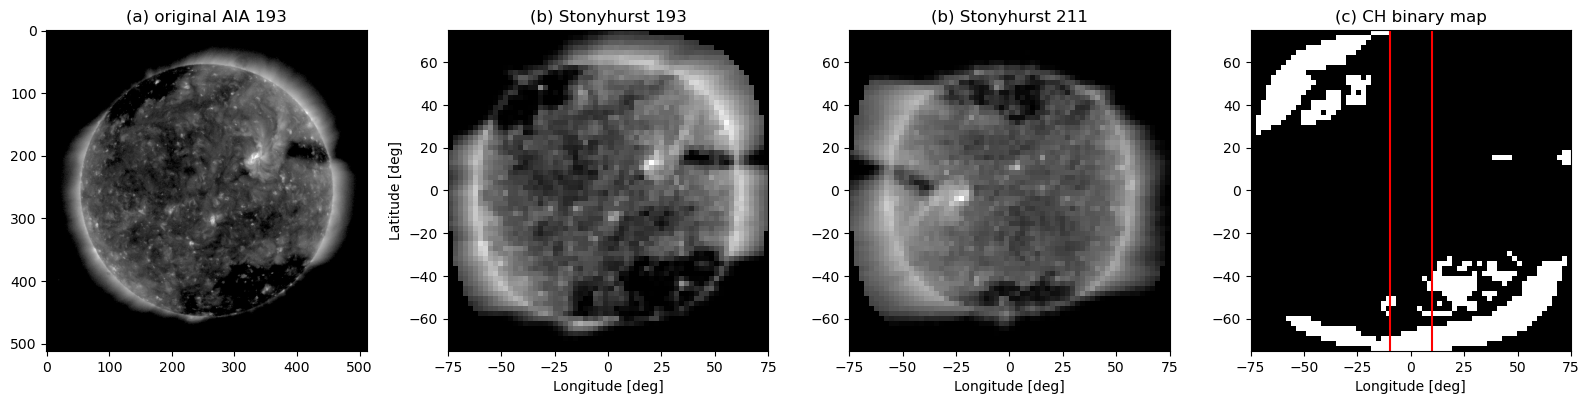

CH area features: {'ch_area_full_disk': np.float32(0.1215), 'ch_area_meridian_10deg': np.float32(0.0419), 'ch_area_meridian_30deg': np.float32(0.0888), 'ch_area_low_latitude_30deg': np.float32(0.0096)}


In [6]:
# 전처리 결과 확인: 원본 -> Stonyhurst 투영 -> CH 이진맵 (논문 Figure 4에 대응)
sample_row = int(train_dataset.image_indexes[0][-1])
sample_maps = np.asarray(train_image_array[sample_row], dtype=np.float32)
sample_name = train_filenames[sample_row]
extent = [-PROJECTION_LON_LIMIT, PROJECTION_LON_LIMIT,
          -PROJECTION_LAT_LIMIT, PROJECTION_LAT_LIMIT]

figure, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(open_gray(DATA_ROOT / "train" / CHANNELS[0] / sample_name), cmap="gray")
axes[0].set_title(f"(a) original AIA {CHANNELS[0]}")
for position, channel in enumerate(CHANNELS):
    axes[position + 1].imshow(sample_maps[position], cmap="gray", extent=extent)
    axes[position + 1].set_title(f"(b) Stonyhurst {channel}")
    axes[position + 1].set_xlabel("Longitude [deg]")
axes[3].imshow(sample_maps[len(CHANNELS)], cmap="gray", extent=extent)
axes[3].axvline(-CENTRAL_MERIDIAN_BANDS[0], color="red")
axes[3].axvline(CENTRAL_MERIDIAN_BANDS[0], color="red")
axes[3].set_title("(c) CH binary map")
axes[3].set_xlabel("Longitude [deg]")
axes[1].set_ylabel("Latitude [deg]")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "preprocessing.png", dpi=120)
plt.show()

print("CH area features:",
      dict(zip(CH_FEATURE_NAMES, np.round(train_ch_features[sample_row], 4))))


## 3. SpeedNet (논문 Figure 7)

```
Data Input (3ch: 193 A / 211 A / CH binary map)
  -> Conv.Block x4   [Conv2D + ReLU + MaxPool],  채널 16 -> 32 -> 64 -> 128
  -> LSTM (100 units)
  -> FFNN (200 units)
  -> Output Unit (예측 태양풍 속도)
```

- Conv.Block은 논문 Fig. 7의 `Convolution layer + MaxPooling` 구성 그대로이고,
  채널 진행(16/32/64/128)과 4블록 깊이도 논문 표기
  (`256x256x16 -> 125x125x32 -> 60x60x64 -> 28x28x128`)를 따랐습니다.
- 논문은 맵 1장 -> 속도 1개이지만 대회는 20시점 -> 12개이므로, **가중치를 공유하는 CNN을 20시점에
  각각 적용**한 뒤 LSTM(100)이 시간축을 훑고 마지막 hidden state를 특징으로 씁니다
  (baseline의 LSTM 처리 방식과 동일).
- wind 브랜치는 baseline 구조(Linear->SELU->Linear->SELU)를 유지하되, 입력에
  시점별 CH 면적 특징(전면적 / 중심자오선 +-10도, +-30도 / 저위도)을 함께 넣습니다.
- 출력 유닛만 논문의 1개에서 대회 요구인 12개(6~72시간)로 바꿨습니다.


In [7]:
class SpeedNetConvBlock(nn.Module):
    # 논문 Fig. 7의 SpeedNet Conv. Block: Convolution layer -> ReLU -> MaxPooling
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        return self.pool(F.relu(self.conv(x), inplace=True))


class SpeedNet(nn.Module):
    def __init__(self, lstm_units=LSTM_UNITS, ffnn_units=FFNN_UNITS):
        super().__init__()
        blocks = []
        in_channels = len(MAP_CHANNELS)
        for out_channels in CONV_CHANNELS:
            blocks.append(SpeedNetConvBlock(in_channels, out_channels))
            in_channels = out_channels
        self.conv_blocks = nn.Sequential(*blocks)
        spatial = IMAGE_SIZE // (2 ** len(CONV_CHANNELS))
        self.feature_dim = CONV_CHANNELS[-1] * spatial * spatial
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=lstm_units,
            batch_first=True,
        )
        self.wind_encoder = nn.Sequential(
            nn.Linear(WIND_FEATURE_DIM, 128), nn.SELU(inplace=True),
            nn.Linear(128, 64), nn.SELU(inplace=True),
        )
        # 논문 Fig. 7의 FFNN. 출력 유닛만 1개 -> 12개(6~72시간)로 바꿨습니다.
        self.head = nn.Sequential(
            nn.Linear(lstm_units + 64, ffnn_units), nn.ReLU(inplace=True),
            nn.Linear(ffnn_units, 12),
        )

    def forward(self, images, wind):
        batch_size, steps = images.shape[0], images.shape[1]
        # 가중치를 공유하는 Conv. Block을 20시점에 각각 적용합니다.
        image_features = self.conv_blocks(images.flatten(0, 1))
        image_features = image_features.reshape(batch_size, steps, -1)
        _, (hidden, _) = self.lstm(image_features)
        image_features = F.relu(hidden[-1])
        wind_features = self.wind_encoder(wind)
        return self.head(torch.cat([image_features, wind_features], dim=1))


model = SpeedNet().to(DEVICE)
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("trainable parameters:", f"{trainable_parameters:,}")


SpeedNet(
  (conv_blocks): Sequential(
    (0): SpeedNetConvBlock(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): SpeedNetConvBlock(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): SpeedNetConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): SpeedNetConvBlock(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (lstm): LSTM(2048, 100, batch_first=True)
  (wind_encoder): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): 

## 4. GPU 학습 - 논문 Table 4 하이퍼파라미터

| 항목 | 논문 값 | code_n1 |
|---|---|---|
| Optimizer | Adam | Adam |
| Learning rate | 0.0001 (고정, 스케줄러 없음) | 동일 |
| Loss | MSE | 동일 |
| Epoch | 100 | 100 (20분 예산 도달 시 조기 종료) |
| Model callback | min validation loss | 동일 |
| Early stopping | patience = 20 | 동일 |
| LSTM units | 100 | 100 |
| FFNN units | 200 (EUV) | 200 |
| Batch size | 12 | 64 (`PAPER_EXACT_BATCH_SIZE=True`로 12 복원) |

baseline의 `ReduceLROnPlateau`는 논문에 없으므로 제거하고 lr을 1e-4로 고정했습니다.


initialized model from scratch; removed any previous checkpoint
training budget: 1039s
epoch=001 train_rmse=170.585 val_rmse=90.233 lr=1.00e-04 seconds=22.1 total=33s
epoch=002 train_rmse=83.724 val_rmse=82.987 lr=1.00e-04 seconds=20.7 total=54s
epoch=003 train_rmse=73.320 val_rmse=76.819 lr=1.00e-04 seconds=21.0 total=75s
epoch=004 train_rmse=68.283 val_rmse=75.287 lr=1.00e-04 seconds=21.3 total=96s
epoch=005 train_rmse=64.982 val_rmse=72.932 lr=1.00e-04 seconds=20.6 total=117s
epoch=006 train_rmse=62.998 val_rmse=72.489 lr=1.00e-04 seconds=20.6 total=138s
epoch=007 train_rmse=61.177 val_rmse=71.106 lr=1.00e-04 seconds=20.6 total=158s
epoch=008 train_rmse=59.614 val_rmse=72.645 lr=1.00e-04 seconds=21.2 total=179s
epoch=009 train_rmse=58.143 val_rmse=73.149 lr=1.00e-04 seconds=20.6 total=200s
epoch=010 train_rmse=56.078 val_rmse=72.129 lr=1.00e-04 seconds=21.0 total=221s
epoch=011 train_rmse=55.066 val_rmse=71.571 lr=1.00e-04 seconds=20.8 total=242s
epoch=012 train_rmse=53.134 val_rmse

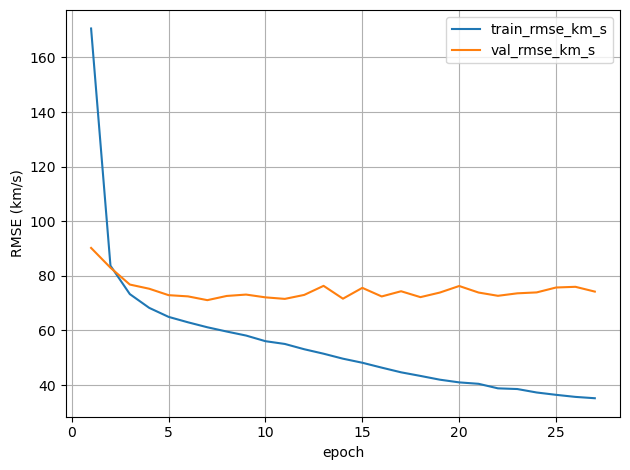

loaded best epoch: 7 val_rmse: 71.106


In [8]:
# 매 학습 실행마다 새 모델을 만들며 pretrained/이전 실행 weight는 불러오지 않습니다.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
model = SpeedNet().to(DEVICE)
# 논문 Table 4: Adam, lr=0.0001 고정 (learning rate scheduler 없음)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# AMP는 GPU 메모리 사용량을 줄이고 연산을 가속합니다.
scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
checkpoint_path = OUTPUT_DIR / "best_model.pth"
if checkpoint_path.exists():
    checkpoint_path.unlink()
print("initialized model from scratch; removed any previous checkpoint")

best_val_rmse = float("inf")
epochs_without_improvement = 0
history = []

training_started = time.perf_counter()
train_budget_seconds = max(60.0, remaining_seconds() - INFERENCE_RESERVE_SECONDS)
print(f"training budget: {train_budget_seconds:.0f}s")


def run_epoch(loader, training):
    model.train(training)
    squared_error_sum = 0.0
    value_count = 0
    for batch in loader:
        images = batch["images"].to(DEVICE, non_blocking=PIN_MEMORY)
        wind = batch["wind"].to(DEVICE, non_blocking=PIN_MEMORY)
        target = batch["target"].to(DEVICE, non_blocking=PIN_MEMORY)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
                prediction = model(images, wind)
                # 논문 Table 4의 loss function: Mean Squared Error
                loss = F.mse_loss(prediction, target)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        # 사용자에게 익숙한 km/s 단위로 되돌려 전체 원소 기준 RMSE를 누적합니다.
        error_km_s = (prediction.detach().float() - target) * 1000.0
        squared_error_sum += float(torch.sum(error_km_s ** 2).cpu())
        value_count += error_km_s.numel()
    return math.sqrt(squared_error_sum / value_count)


for epoch in range(1, EPOCHS + 1):
    started = time.perf_counter()
    train_rmse = run_epoch(train_loader, training=True)
    with torch.no_grad():
        val_rmse = run_epoch(val_loader, training=False)
    elapsed = time.perf_counter() - started
    history.append({
        "epoch": epoch,
        "train_rmse_km_s": train_rmse,
        "val_rmse_km_s": val_rmse,
        "learning_rate": LEARNING_RATE,
        "seconds": elapsed,
    })
    print(
        f"epoch={epoch:03d} train_rmse={train_rmse:.3f} "
        f"val_rmse={val_rmse:.3f} lr={LEARNING_RATE:.2e} "
        f"seconds={elapsed:.1f} total={elapsed_seconds():.0f}s"
    )
    # 논문 Table 4의 model callback: validation loss가 가장 낮은 epoch만 보관합니다.
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        epochs_without_improvement = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_rmse_km_s": val_rmse,
                "channels": CHANNELS,
                "map_channels": MAP_CHANNELS,
                "image_size": IMAGE_SIZE,
                "log_mean": LOG_MEAN,
                "log_std": LOG_STD,
                "ch_ratio": CH_RATIO,
                "geometry": [grid["geometry"] for grid in GRIDS],
                "hyperparameters": {
                    "lstm_units": LSTM_UNITS,
                    "ffnn_units": FFNN_UNITS,
                    "conv_channels": list(CONV_CHANNELS),
                    "learning_rate": LEARNING_RATE,
                    "batch_size": BATCH_SIZE,
                },
                "initialization": "random_from_scratch",
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1
        # 논문 Table 3: early stopping patience = 20
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("early stopping")
            break
    # 20분 예산: 다음 epoch을 돌릴 시간이 없으면 여기서 멈추고 추론으로 넘어갑니다.
    spent = time.perf_counter() - training_started
    if spent + elapsed > train_budget_seconds:
        print(f"time budget reached ({spent:.0f}s); stopping training")
        break

history_frame = pd.DataFrame(history)
history_frame.to_csv(OUTPUT_DIR / "history.csv", index=False)
history_frame.plot(x="epoch", y=["train_rmse_km_s", "val_rmse_km_s"], grid=True)
plt.ylabel("RMSE (km/s)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curve.png", dpi=140)
plt.show()

checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print("loaded best epoch:", checkpoint["epoch"],
      "val_rmse:", round(checkpoint["val_rmse_km_s"], 3))


## 5. Validation 데이터 평가

baseline과 동일합니다. persistence 대비 개선 폭으로 SpeedNet 이식 효과를 확인합니다.


In [9]:
@torch.no_grad()
def predict(loader):
    model.eval()
    predictions = []
    sample_ids = []
    for batch in loader:
        images = batch["images"].to(DEVICE, non_blocking=PIN_MEMORY)
        wind = batch["wind"].to(DEVICE, non_blocking=PIN_MEMORY)
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            output = model(images, wind)
        predictions.append(output.float().cpu().numpy() * 1000.0)
        sample_ids.extend(batch["sample_id"])
    return np.concatenate(predictions), sample_ids


validation_prediction, validation_ids = predict(val_loader)
validation_target = np.asarray(val_targets[val_index], dtype=np.float64)
assert validation_ids == val_inputs.iloc[val_index].sample_id.tolist()

# persistence baseline: 마지막 관측 wind가 72시간 동안 유지된다고 가정
validation_persistence = np.repeat(
    val_inputs.iloc[val_index][[WIND_COLUMNS[-1]]].to_numpy(np.float64), 12, axis=1
)


def metrics_by_horizon(y_true, y_pred):
    rows = []
    for index in range(12):
        actual = y_true[:, index]
        predicted = y_pred[:, index]
        error = predicted - actual
        denominator = np.std(actual) * np.std(predicted)
        correlation = (
            float(np.corrcoef(actual, predicted)[0, 1]) if denominator > 0 else np.nan
        )
        rows.append({
            "horizon_hours": (index + 1) * 6,
            "rmse_km_s": float(np.sqrt(np.mean(error ** 2))),
            "mae_km_s": float(np.mean(np.abs(error))),
            "correlation": correlation,
        })
    return pd.DataFrame(rows)


validation_metrics = metrics_by_horizon(validation_target, validation_prediction)
persistence_metrics = metrics_by_horizon(validation_target, validation_persistence)
validation_metrics["persistence_rmse_km_s"] = persistence_metrics.rmse_km_s
validation_metrics.to_csv(OUTPUT_DIR / "validation_metrics.csv", index=False)
print(
    "overall validation RMSE:",
    float(np.sqrt(np.mean((validation_prediction - validation_target) ** 2))),
)
print(
    "persistence  validation RMSE:",
    float(np.sqrt(np.mean((validation_persistence - validation_target) ** 2))),
)
validation_metrics


overall validation RMSE: 71.10581003055708
persistence  validation RMSE: 87.5884266635981


,horizon_hours,rmse_km_s,mae_km_s,correlation,persistence_rmse_km_s
0,6,41.490354,29.929526,0.895282,30.133799
1,12,53.744901,38.831194,0.818207,49.612603
2,18,62.033251,45.251464,0.749974,63.040371
3,24,67.352344,49.854092,0.701333,73.255360
4,30,72.806720,53.065927,0.645748,82.029491
5,36,73.746890,54.478012,0.628888,89.150125
6,42,76.834353,57.297725,0.591365,94.699058
7,48,77.666060,58.451214,0.580670,99.061863
8,54,78.041792,59.741614,0.573932,102.730158
9,60,78.205271,60.436699,0.574533,105.953524


## 6. Test 추론 및 submission.csv 생성

`submission/` 아래에 `model.pth`, `submission.csv`를 저장합니다.
제출 전 이 notebook을 `submission/code.ipynb`로 복사해 주세요.


In [10]:
# test 추론 전에 학습용 객체와 CUDA cache를 정리해 불필요한 메모리를 반환합니다.
del train_loader, val_loader, train_dataset, val_dataset
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

test_dataset = SpeedNetDataset(
    test_image_array, test_ch_features, test_image_index, test_inputs, test_index,
    LOG_MEAN, LOG_STD, targets=None,
)
test_loader = make_loader(test_dataset, shuffle=False)
test_prediction, predicted_ids = predict(test_loader)
expected_ids = test_inputs.iloc[test_index].sample_id.tolist()
assert predicted_ids == expected_ids
assert test_prediction.shape == (len(test_index), 12)
assert np.isfinite(test_prediction).all()

# 제출 형식은 sample_id 다음에 target_00~target_11이 오는 13개 column입니다.
submission = pd.DataFrame(test_prediction, columns=TARGET_COLUMNS)
submission.insert(0, "sample_id", predicted_ids)
submission.to_csv(OUTPUT_DIR / "submission.csv", index=False)
submission.to_csv(SUBMISSION_DIR / "submission.csv", index=False)
torch.save(checkpoint, SUBMISSION_DIR / "model.pth")

assert submission.columns.tolist() == ["sample_id"] + TARGET_COLUMNS
assert submission.sample_id.is_unique
assert len(submission) == len(test_inputs)

print("saved:", (SUBMISSION_DIR / "submission.csv").resolve())
print("saved:", (SUBMISSION_DIR / "model.pth").resolve())
print("shape:", submission.shape)
print(f"total elapsed: {elapsed_seconds():.0f}s / budget {TOTAL_BUDGET_SECONDS}s")

del test_dataset, test_loader
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

submission.head()


saved: /home/jovyan/submission/submission.csv
saved: /home/jovyan/submission/model.pth
shape: (3868, 13)
total elapsed: 585s / budget 1200s


,sample_id,target_00,target_01,target_02,target_03,target_04,target_05,target_06,target_07,target_08,target_09,target_10,target_11
0,sample_07393cebc8e6882a,652.832031,641.601562,633.789062,629.394531,620.117188,592.773438,591.796875,565.917969,544.433594,531.738281,508.789062,502.929688
1,sample_640b9e2639db9b4f,394.042969,396.728516,397.949219,400.146484,393.066406,383.056641,391.845703,382.324219,383.300781,383.300781,385.009766,382.812500
2,sample_cd1159b14b325e4b,405.273438,400.390625,383.544922,385.253906,362.792969,369.140625,366.455078,366.455078,374.023438,380.371094,369.873047,379.638672
3,sample_cdb23a4bf60ec4df,373.779297,372.558594,367.187500,357.666016,353.027344,354.492188,358.154297,361.572266,366.699219,369.628906,376.708984,380.859375
4,sample_3713237d245e38bb,403.808594,416.992188,435.546875,429.199219,436.767578,441.894531,444.580078,451.904297,438.476562,441.894531,441.406250,440.429688
